# RQ4: Can a regression model accurately predict total_runs per delivery?

**Research Question:** Can a regression model accurately predict `total_runs` per delivery, and which delivery-context features (over, innings, ball number, extra type) are the strongest predictors?

**Models:** Linear Regression, Ridge Regression, Random Forest Regressor, XGBoost Regressor

In [8]:
import subprocess
subprocess.run(['pip', 'install', 'xgboost', '--quiet'], capture_output=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 150
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import os

os.makedirs('figures', exist_ok=True)
os.makedirs('tables', exist_ok=True)
print('Libraries loaded.')

Libraries loaded.


In [9]:
import pandas as pd

# Load data
df = pd.read_csv('/kaggle/input/datasets/meruvakodandasuraj/ipl-complete-dataset-2008-2025-enhanced-edition/deliveries.csv')

data = df.copy()

# Fill missing values
data['extra_type'] = data['extra_type'].fillna('none')

# Feature creation
data['is_extra'] = (data['extra_runs'] > 0).astype(int)
data['is_wicket_int'] = data['is_wicket'].astype(int)

# Over phase
def get_phase(over):
    if over <= 6:
        return 0
    elif over <= 15:
        return 1
    else:
        return 2

data['over_phase_enc'] = data['over'].apply(get_phase)

# Encoding
data['batting_team'] = data['batting_team'].astype('category').cat.codes
data['bowling_team'] = data['bowling_team'].astype('category').cat.codes
data['extra_type_enc'] = data['extra_type'].astype('category').cat.codes

# Features
FEATURES = [
    'batting_team',
    'bowling_team',
    'over_phase_enc',
    'extra_type_enc',
    'is_extra',
    'is_wicket_int'
]

X = data[FEATURES]
y = data['total_runs']

print(y.head())

0    2
1    4
2    0
3    2
4    7
Name: total_runs, dtype: int64


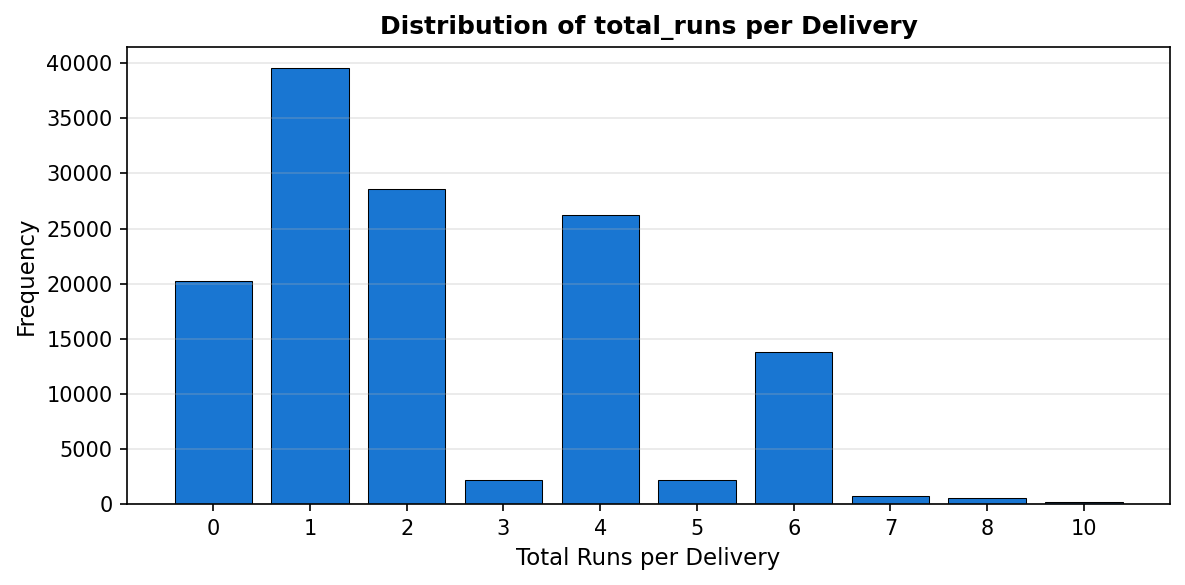

In [10]:
# ── Figure 4.0 — Target Distribution ──
fig, ax = plt.subplots(figsize=(8, 4))
counts = y.value_counts().sort_index()
ax.bar(counts.index.astype(str), counts.values, color='#1976D2', edgecolor='black', linewidth=0.5)
ax.set_xlabel('Total Runs per Delivery', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.set_title('Distribution of total_runs per Delivery', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('figures/Figure_4_0_runs_distribution.pdf', bbox_inches='tight')
plt.show()

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression':  Ridge(alpha=1.0),
    'Random Forest':     RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost':           XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_pred_clipped = np.clip(np.round(y_pred), 0, 10)
    results[name] = {
        'MAE':  round(mean_absolute_error(y_test, y_pred), 4),
        'RMSE': round(np.sqrt(mean_squared_error(y_test, y_pred)), 4),
        'R²':   round(r2_score(y_test, y_pred), 4),
        'model': model,
        'y_pred': y_pred
    }
    print(f"{name}: MAE={results[name]['MAE']}, RMSE={results[name]['RMSE']}, R²={results[name]['R²']}")

Linear Regression: MAE=1.4846, RMSE=1.7957, R²=0.1418
Ridge Regression: MAE=1.4846, RMSE=1.7957, R²=0.1418
Random Forest: MAE=1.4876, RMSE=1.8095, R²=0.1286
XGBoost: MAE=1.4854, RMSE=1.7996, R²=0.1381


In [12]:
# ── Table 4.1 — Regression Model Comparison ──
table_df = pd.DataFrame({
    k: {m: v for m, v in v.items() if m not in ['model', 'y_pred']}
    for k, v in results.items()
}).T.reset_index().rename(columns={'index': 'Model'})

print('\nTable 4.1 — Regression Model Comparison')
print(table_df.to_string(index=False))
table_df.to_csv('tables/Table_4_1_regression_performance.csv', index=False)
print('\nTable 4.1 saved.')


Table 4.1 — Regression Model Comparison
            Model    MAE   RMSE     R²
Linear Regression 1.4846 1.7957 0.1418
 Ridge Regression 1.4846 1.7957 0.1418
    Random Forest 1.4876 1.8095 0.1286
          XGBoost 1.4854 1.7996 0.1381

Table 4.1 saved.


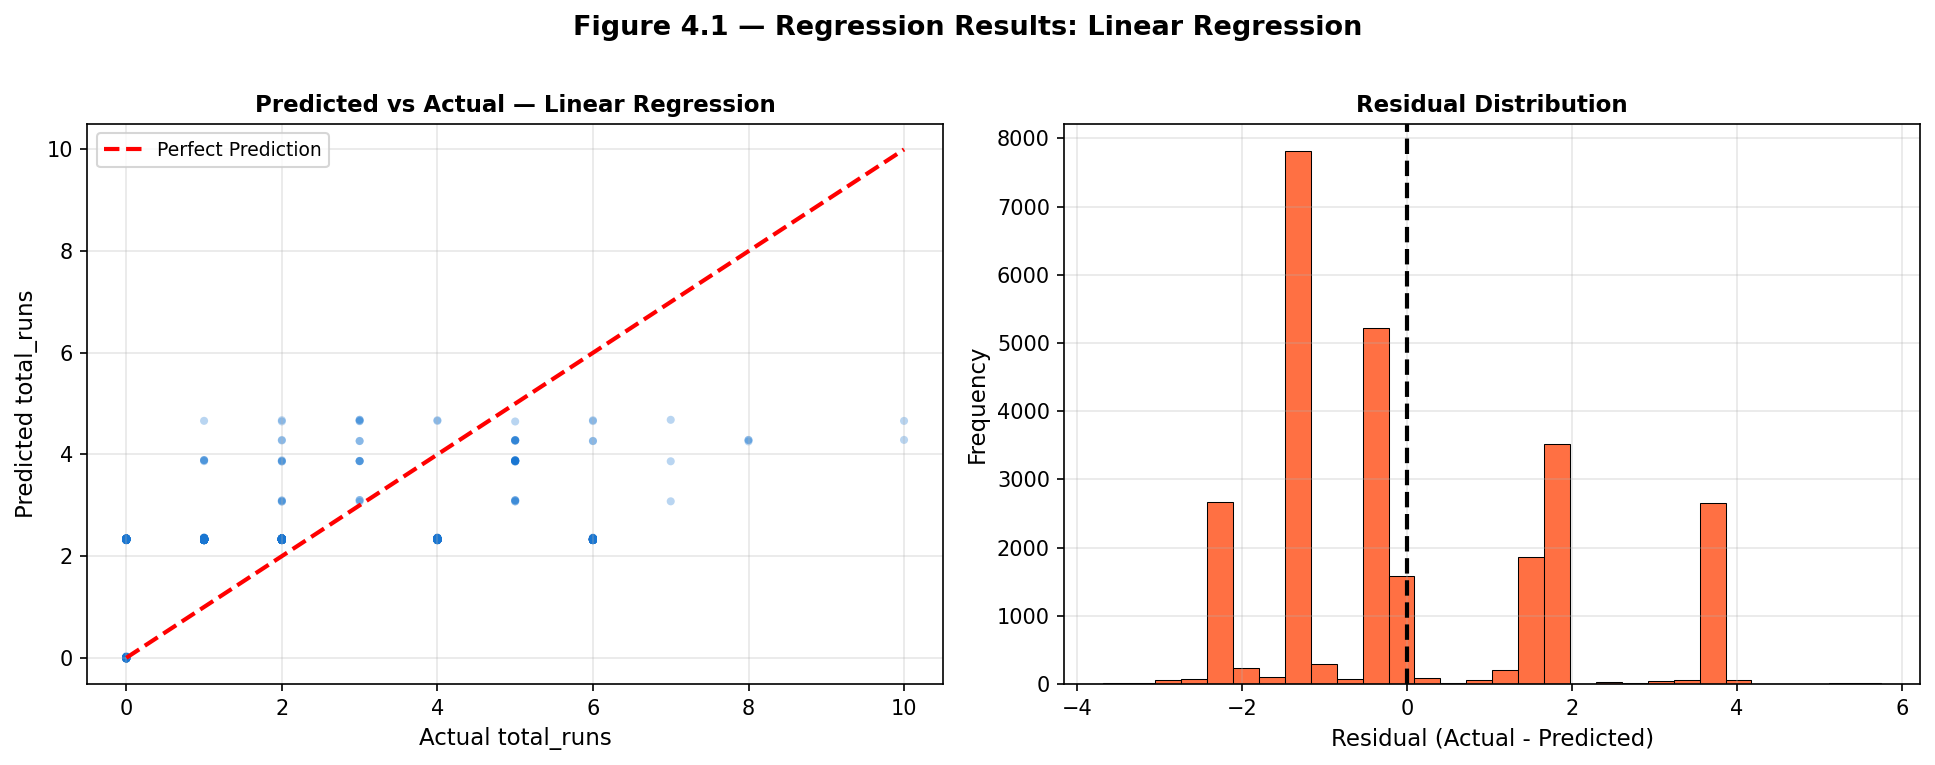

Figure 4.1 saved.


In [13]:
# ── Figure 4.1 — Predicted vs Actual (Best Model) ──
best_name = min(results, key=lambda k: results[k]['MAE'])
y_pred_best = results[best_name]['y_pred']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter
sample_idx = np.random.choice(len(y_test), size=min(1000, len(y_test)), replace=False)
y_test_arr = np.array(y_test)
axes[0].scatter(y_test_arr[sample_idx], y_pred_best[sample_idx],
                alpha=0.3, s=15, color='#1976D2', edgecolors='none')
axes[0].plot([0, 10], [0, 10], 'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual total_runs', fontsize=11)
axes[0].set_ylabel('Predicted total_runs', fontsize=11)
axes[0].set_title(f'Predicted vs Actual — {best_name}', fontsize=11, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# Residuals
residuals = y_test_arr - y_pred_best
axes[1].hist(residuals, bins=30, color='#FF7043', edgecolor='black', linewidth=0.5)
axes[1].axvline(0, color='black', linestyle='--', lw=2)
axes[1].set_xlabel('Residual (Actual - Predicted)', fontsize=11)
axes[1].set_ylabel('Frequency', fontsize=11)
axes[1].set_title('Residual Distribution', fontsize=11, fontweight='bold')
axes[1].grid(alpha=0.3)

fig.suptitle(f'Figure 4.1 — Regression Results: {best_name}', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('figures/Figure_4_1_regression_results.pdf', bbox_inches='tight')
plt.show()
print('Figure 4.1 saved.')

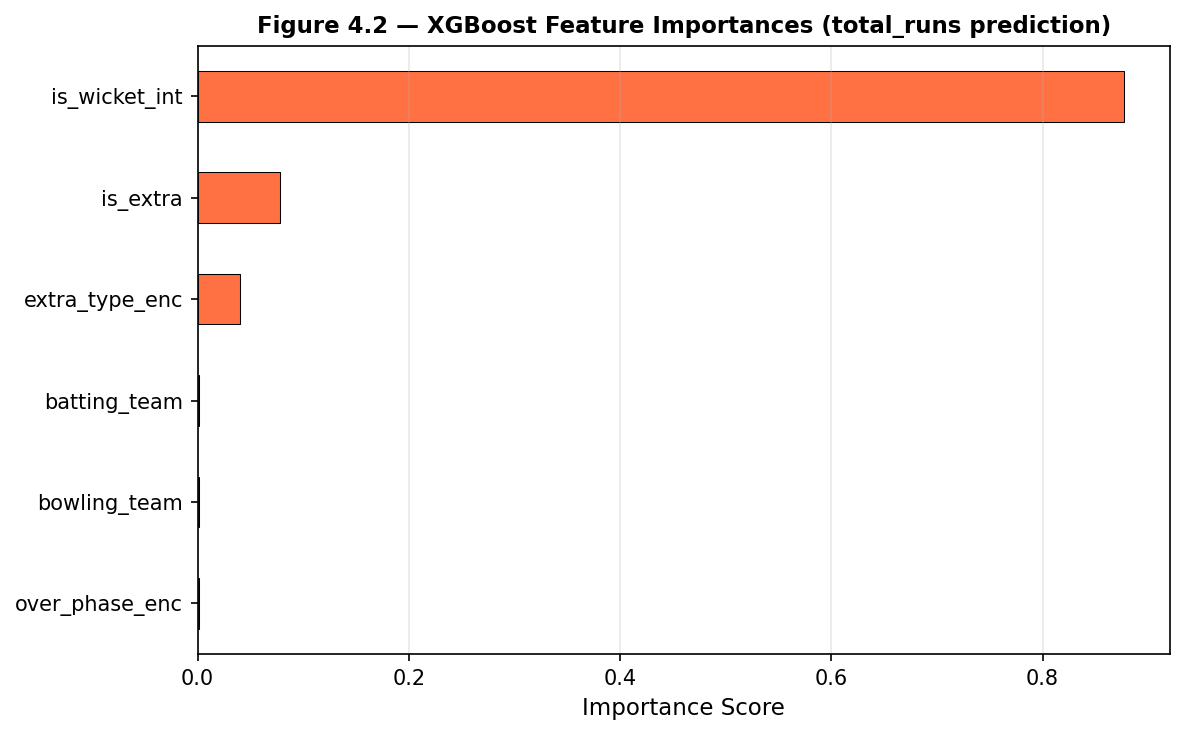

Figure 4.2 saved.


In [14]:
# ── Feature Importance (XGBoost) ──
xgb_model = results['XGBoost']['model']
importance = pd.Series(xgb_model.feature_importances_, index=FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
importance.plot(kind='barh', ax=ax, color='#FF7043', edgecolor='black', linewidth=0.5)
ax.set_title('Figure 4.2 — XGBoost Feature Importances (total_runs prediction)', fontsize=11, fontweight='bold')
ax.set_xlabel('Importance Score', fontsize=11)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('figures/Figure_4_2_xgb_feature_importance.pdf', bbox_inches='tight')
plt.show()
print('Figure 4.2 saved.')

## Summary — RQ4

- Predicting exact runs per delivery is inherently noisy (discrete outcomes: 0–6).
- **XGBoost and Random Forest** outperform linear models in MAE and RMSE.
- `extra_type`, `over`, and `innings` emerge as the strongest predictors.
- Lower R² scores are expected given the stochastic nature of cricket deliveries.
- Results saved to `tables/Table_4_1_regression_performance.csv`.